In [9]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath("../src"))

from processes import simulate_gbm_paths

In [2]:
def simulate_brownian_path(T: float, n_steps: int, seed: int = None) -> tuple:
    """
    Simulate one path of standard Brownian motion W on [0, T].

    Parameters
    ----------
    T       : float  — terminal time (e.g. T=1 means one year)
    n_steps : int    — number of discrete time steps
    seed    : int    — optional RNG seed for reproducibility

    Returns
    -------
    t : np.ndarray, shape (n_steps+1,) — time grid t_0, t_1, ..., t_n
    W : np.ndarray, shape (n_steps+1,) — simulated path W_0, W_1, ..., W_n
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    
    # Draw n_steps independent N(0,1) increments: Z_0, Z_1, ..., Z_{n-1}
    Z = rng.standard_normal(n_steps)
    
    # Scale to get Brownian increments
    dW = np.sqrt(dt) * Z
    
    # Cumulative sum gives the paths and need to prepend W_0 = 0
    W = np.concatenate([[0.0], np.cumsum(dW)])
    
    t = np.linspace(0, T, n_steps+1)
    
    return t, W

In [3]:
def plot_brownian_paths(T: float, n_steps: int, n_paths: int, seed: int = 37):
    """
    Plot multiple independent Brownian motion paths on [0, T].
    
    Parameters
    ----------
    T       : float — terminal time
    n_steps : int   — discretisation steps per path
    n_paths : int   — number of independent paths to draw
    seed    : int   — base seed (each path gets seed+i for reproducibility)
    """
    fig, ax = plt.subplots(figsize=(10,5))
    
    for i in range(n_paths):
        t, W = simulate_brownian_path(T, n_steps, seed=seed+i)
        ax.plot(t, W, lw=0.8, alpha=0.7)
       
    # Reference lines
    ax.axhline(0, color='black', lw=1.0, ls='--', label='$W_0 = 0$')

    # 1-sigma envelope: std dev of W_t is sqrt(t)
    t_grid = np.linspace(0, T, 300)
    ax.fill_between(t_grid, -np.sqrt(t_grid), np.sqrt(t_grid),
                    alpha=0.12, color='steelblue', label=r'$\pm\sqrt{t}$ envelope')

    ax.set_xlabel('Time $t$')
    ax.set_ylabel('$W_t$')
    ax.set_title(f'Standard Brownian Motion — {n_paths} paths, $T={T}$, $n={n_steps}$ steps')
    ax.legend()
    plt.tight_layout()
    plt.show()

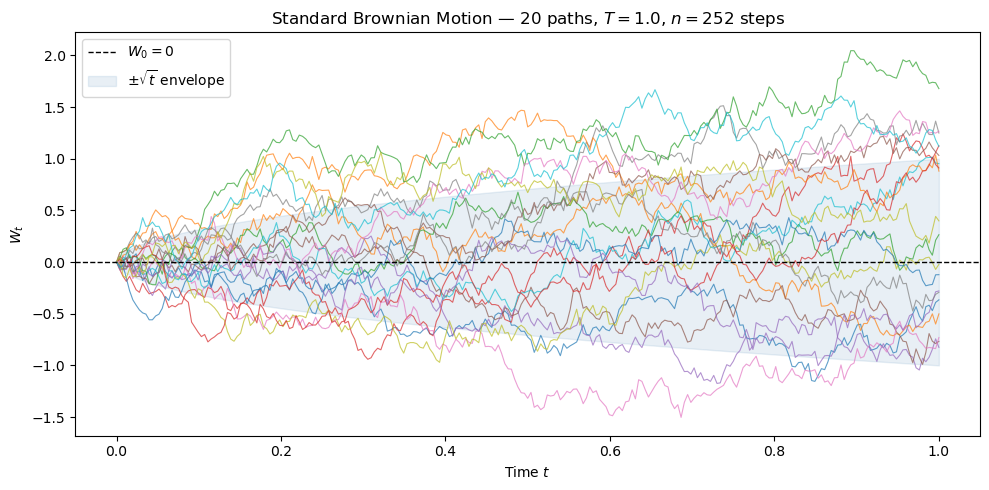

In [4]:
plot_brownian_paths(T=1.0, n_steps=252, n_paths=20, seed=37)

In [5]:
def verify_brownian_statistics(T: float, n_steps: int, n_paths: int, seed: int = 0):
    """
    Verify simulated BM against theoretical moments:
      E[W_T]        = 0
      Var[W_T]      = T
      E[W_T^2]      = T   (since Var = E[X^2] - E[X]^2 and E[X]=0)
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps

    # Simulate n_paths terminal values W_T in one vectorised call
    # Each path: sum of n_steps iid N(0, dt) increments
    Z = rng.standard_normal((n_paths, n_steps))   # shape (n_paths, n_steps)
    W_T = np.sum(np.sqrt(dt) * Z, axis=1)         # shape (n_paths,) — one W_T per path

    print(f"Theoretical  E[W_T]   = {0:.6f}")
    print(f"Simulated    E[W_T]   = {W_T.mean():.6f}")
    print()
    print(f"Theoretical  Var[W_T] = {T:.6f}")
    print(f"Simulated    Var[W_T] = {W_T.var():.6f}")

verify_brownian_statistics(T=1.0, n_steps=252, n_paths=100_000, seed=0)

Theoretical  E[W_T]   = 0.000000
Simulated    E[W_T]   = 0.002516

Theoretical  Var[W_T] = 1.000000
Simulated    Var[W_T] = 0.994495


In [10]:
# Check Mean and Variance against theoretical values
# Chosen random sample values
S0 = 100
mu = 0.05
sigma = 0.2
T = 1.0
n_steps = 252
n_paths = 10000
seed = 66
t, S = simulate_gbm_paths(S0, mu, sigma, T, n_steps, n_paths, seed=None)
ST = S[:, -1]

emp_mean = np.mean(ST)
emp_var = np.var(ST)

theo_mean = S0 * np.exp(mu * T)
theo_var = (S0**2) * np.exp(2*mu*T) * (np.exp((sigma**2)*T) - 1)

print("\n=== GBM: Empirical vs Theoretical ===")
print("-" * 50)

print(f"Mean:")
print(f"  Empirical    : {emp_mean:15.6f}")
print(f"  Theoretical  : {theo_mean:15.6f}")
print(f"  Difference   : {abs(emp_mean - theo_mean):15.6f} ")

print(f"\nVariance:")
print(f"  Empirical    : {emp_var:15.6f}")
print(f"  Theoretical  : {theo_var:15.6f}")
print(f"  Difference   : {abs(emp_var - theo_var):15.6f}")


=== GBM: Empirical vs Theoretical ===
--------------------------------------------------
Mean:
  Empirical    :      105.107414
  Theoretical  :      105.127110
  Difference   :        0.019696 

Variance:
  Empirical    :      451.664559
  Theoretical  :      451.028808
  Difference   :        0.635751


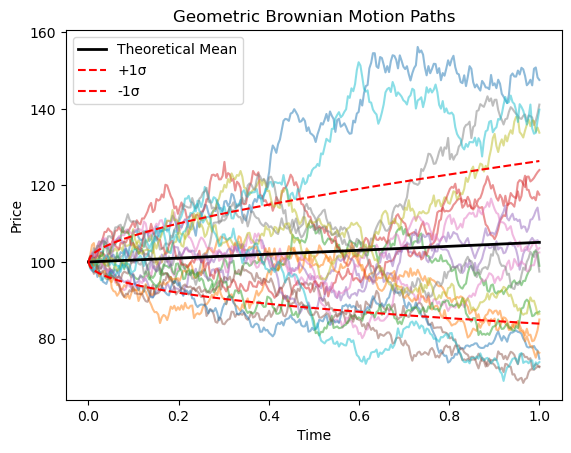

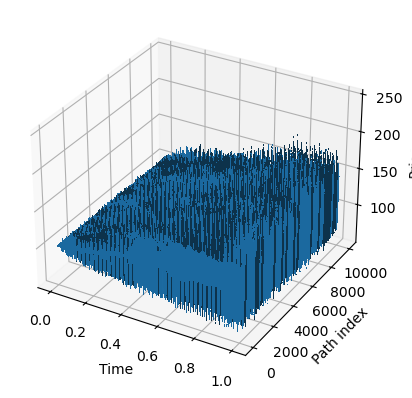

In [12]:
# Visualisation
S_sample = S[:20, :]  # First 20 paths
time_grid = t

# Theoretical Mean path
theo_mean_path = S0 * np.exp(mu * time_grid)

# Time-dependent variance and std
theo_var_t = theo_var = (S0**2) * np.exp(2*mu*time_grid) * (np.exp((sigma**2)*time_grid) - 1)
theo_std_t = np.sqrt(theo_var_t)

upper_band = theo_mean_path + theo_std_t
lower_band = theo_mean_path - theo_std_t

plt.figure()

# Plot sample paths
for i in range(S_sample.shape[0]):
    plt.plot(time_grid, S_sample[i], alpha=0.5)

# Plot theoretical mean
plt.plot(time_grid, theo_mean_path, color='black', linewidth=2, label='Theoretical Mean')

# Plot std envelope
plt.plot(time_grid, upper_band, linestyle='--', color='red', label='+1σ')
plt.plot(time_grid, lower_band, linestyle='--', color='red', label='-1σ')

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Geometric Brownian Motion Paths")
plt.legend()

plt.show()


# =========================
# Optional: 3D surface plot (exploratory)
# =========================
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

path_indices = np.arange(S.shape[0])
T_grid, P_grid = np.meshgrid(time_grid, path_indices)

ax.plot_surface(T_grid, P_grid, S, linewidth=0, antialiased=False)

ax.set_xlabel("Time")
ax.set_ylabel("Path index")
ax.set_zlabel("Price")

plt.show()